# Ternary similarity map with normalized Levenshtein distance

This notebook uses edit distance instead of Hamming distance, so it can handle sequences with different lengths or indels. The ternary interpretation remains relative similarity to the three references. For proteins, however, a substitution-matrix alignment distance is usually more biologically meaningful than uniform edit costs.

## Inputs

All notebooks use the same FASTA inputs bundled in `sequenceTols`: `example_vertices.fasta` for the three references and `example_queries.fasta` for the query sequences. You can replace those paths in the first code cell with your own FASTA files.

In [1]:
from pathlib import Path
import csv
import math
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

REFERENCES_FASTA = Path("example_vertices.fasta")
QUERIES_FASTA = Path("example_queries.fasta")
OUTPUT_PREFIX = Path("notebook_output")


def parse_fasta(path: Path):
    records = []
    header = None
    chunks = []
    with path.open() as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(chunks).upper()))
                header = line[1:].strip() or f"seq_{len(records) + 1}"
                chunks = []
            else:
                chunks.append(line)
    if header is not None:
        records.append((header, "".join(chunks).upper()))
    if not records:
        raise ValueError(f"No FASTA records found in {path}")
    return records


def normalized_hamming(seq_a: str, seq_b: str) -> float:
    if len(seq_a) != len(seq_b):
        raise ValueError("Hamming distance requires equal-length sequences.")
    if len(seq_a) == 0:
        return 0.0
    mismatches = sum(char_a != char_b for char_a, char_b in zip(seq_a, seq_b))
    return mismatches / len(seq_a)


def levenshtein_distance(seq_a: str, seq_b: str) -> int:
    if len(seq_a) < len(seq_b):
        seq_a, seq_b = seq_b, seq_a
    previous = list(range(len(seq_b) + 1))
    for i, char_a in enumerate(seq_a, start=1):
        current = [i]
        for j, char_b in enumerate(seq_b, start=1):
            insert_cost = current[j - 1] + 1
            delete_cost = previous[j] + 1
            substitute_cost = previous[j - 1] + (char_a != char_b)
            current.append(min(insert_cost, delete_cost, substitute_cost))
        previous = current
    return previous[-1]


def normalized_levenshtein(seq_a: str, seq_b: str) -> float:
    scale = max(len(seq_a), len(seq_b))
    if scale == 0:
        return 0.0
    return levenshtein_distance(seq_a, seq_b) / scale


def affinity_linear(distance: float) -> float:
    return max(0.0, 1.0 - distance)


def close_affinities(affinities):
    affinities = np.asarray(affinities, dtype=float)
    total = float(affinities.sum())
    if total <= 0.0:
        return np.full(3, 1.0 / 3.0)
    return affinities / total


def barycentric_to_cartesian(lambdas):
    vertices = np.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, math.sqrt(3.0) / 2.0],
    ])
    return np.asarray(lambdas, dtype=float) @ vertices


def write_csv(path: Path, rows, fieldnames):
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


## Mathematical formulation

This notebook uses the same ternary construction as the Hamming-based notebook, but replaces Hamming distance with normalized Levenshtein distance:
\[
d_A(Q)=d_{\mathrm{Lev}}(Q,A),\qquad d_B(Q)=d_{\mathrm{Lev}}(Q,B),\qquad d_C(Q)=d_{\mathrm{Lev}}(Q,C).
\]
If $\operatorname{Lev}(X,Y)$ is the edit distance between $X$ and $Y$, then
\[
d_{\mathrm{Lev}}(X,Y)=\frac{\operatorname{Lev}(X,Y)}{\max(|X|,|Y|)}.
\]
This allows insertions and deletions and is therefore more appropriate when lengths differ.

Distances are converted to similarities with
\[
s_i(Q)=\max(0,1-d_i(Q)),\qquad i\in\{A,B,C\},
\]
and then closed into a 3-part composition
\[
\lambda_i(Q)=\frac{s_i(Q)}{s_A(Q)+s_B(Q)+s_C(Q)}.
\]
Finally, the ternary point is obtained by barycentric mapping into the equilateral triangle defined by
\[
V_A=(0,0),\qquad V_B=(1,0),\qquad V_C=\left(\frac12,\frac{\sqrt3}{2}\right).
\]

## Interpretation and limitations

The interpretation is the same as in the Hamming notebook: this is a **relative similarity composition**, not a metric embedding of the original edit distances.

Levenshtein distance makes the notebook more flexible for sequences with unequal lengths, but all of the structural limitations of the ternary map remain:

- closure destroys absolute scale,
- the three chosen references define the coordinate system,
- different distance triples can collapse to the same ternary coordinates,
- the result should not be treated as a phylogenetic geometry,
- for proteins, uniform substitution costs ignore the fact that some amino-acid replacements are much milder than others.

This notebook is therefore best viewed as a robust edit-distance baseline rather than the default biological model for proteins.

In [2]:
DISTANCE_FUNCTION = normalized_levenshtein
DISTANCE_NAME = "normalized Levenshtein"
DISTANCE_LABEL = "levenshtein"

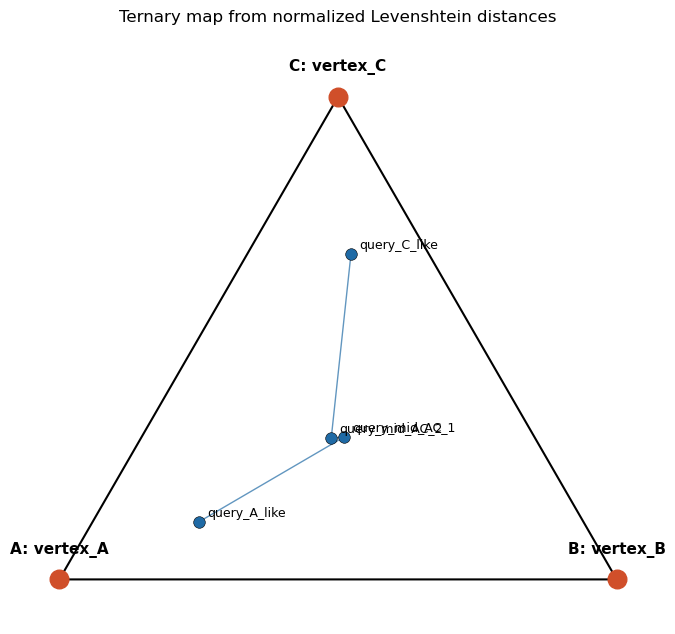

Saved CSV: notebook_output_levenshtein_coordinates.csv
Saved plot: notebook_output_levenshtein_triangle.png
[{'affinity_to_A': 0.9666666666666667,
  'affinity_to_B': 0.2666666666666667,
  'affinity_to_C': 0.16666666666666663,
  'distance_to_A': 0.03333333333333333,
  'distance_to_B': 0.7333333333333333,
  'distance_to_C': 0.8333333333333334,
  'lambda_A': 0.6904761904761906,
  'lambda_B': 0.19047619047619052,
  'lambda_C': 0.11904761904761903,
  'sequence_id': 'query_A_like',
  'x': 0.25000000000000006,
  'y': 0.1030982623552903},
 {'affinity_to_A': 0.5,
  'affinity_to_B': 0.5333333333333333,
  'affinity_to_C': 0.43333333333333335,
  'distance_to_A': 0.5,
  'distance_to_B': 0.4666666666666667,
  'distance_to_C': 0.5666666666666667,
  'lambda_A': 0.34090909090909094,
  'lambda_B': 0.36363636363636365,
  'lambda_C': 0.29545454545454547,
  'sequence_id': 'query_mid_AC_1',
  'x': 0.5113636363636364,
  'y': 0.2558711420272205},
 {'affinity_to_A': 0.5,
  'affinity_to_B': 0.4666666666666667,


In [3]:
reference_records = parse_fasta(REFERENCES_FASTA)
query_records = parse_fasta(QUERIES_FASTA)
assert len(reference_records) == 3, "The references FASTA must contain exactly 3 sequences."

reference_ids = [record[0] for record in reference_records]
reference_sequences = [record[1] for record in reference_records]
rows = []

for query_id, query_sequence in query_records:
    distances = np.array([
        DISTANCE_FUNCTION(query_sequence, ref_sequence)
        for ref_sequence in reference_sequences
    ], dtype=float)
    affinities = np.array([affinity_linear(value) for value in distances], dtype=float)
    lambdas = close_affinities(affinities)
    xy = barycentric_to_cartesian(lambdas)
    rows.append({
        "sequence_id": query_id,
        "distance_to_A": float(distances[0]),
        "distance_to_B": float(distances[1]),
        "distance_to_C": float(distances[2]),
        "affinity_to_A": float(affinities[0]),
        "affinity_to_B": float(affinities[1]),
        "affinity_to_C": float(affinities[2]),
        "lambda_A": float(lambdas[0]),
        "lambda_B": float(lambdas[1]),
        "lambda_C": float(lambdas[2]),
        "x": float(xy[0]),
        "y": float(xy[1]),
    })

fieldnames = list(rows[0].keys())
output_csv = Path(f"{OUTPUT_PREFIX.name}_levenshtein_coordinates.csv")
write_csv(output_csv, rows, fieldnames)

vertex_xy = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.5, math.sqrt(3.0) / 2.0],
])
query_xy = np.array([[row["x"], row["y"]] for row in rows], dtype=float)

fig, ax = plt.subplots(figsize=(7, 7))
triangle = np.vstack((vertex_xy, vertex_xy[0]))
ax.plot(triangle[:, 0], triangle[:, 1], color="black", linewidth=1.5)
ax.scatter(vertex_xy[:, 0], vertex_xy[:, 1], s=180, color="#d04f2a", zorder=3)
ax.scatter(query_xy[:, 0], query_xy[:, 1], s=70, color="#1f6aa5", edgecolor="black", linewidth=0.4, zorder=3)
ax.plot(query_xy[:, 0], query_xy[:, 1], color="#1f6aa5", linewidth=1.0, alpha=0.7, zorder=2)

for label, (x_coord, y_coord) in zip([f"A: {reference_ids[0]}", f"B: {reference_ids[1]}", f"C: {reference_ids[2]}"], vertex_xy):
    ax.text(x_coord, y_coord + 0.04, label, ha="center", va="bottom", fontsize=11, fontweight="bold")

for row in rows:
    ax.text(row["x"] + 0.015, row["y"] + 0.01, row["sequence_id"], fontsize=9)

ax.set_title("Ternary map from normalized Levenshtein distances")
ax.set_xlim(-0.08, 1.08)
ax.set_ylim(-0.08, math.sqrt(3.0) / 2.0 + 0.12)
ax.set_aspect("equal")
ax.axis("off")
fig.tight_layout()

output_png = Path(f"{OUTPUT_PREFIX.name}_levenshtein_triangle.png")
fig.savefig(output_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved CSV: {output_csv}")
print(f"Saved plot: {output_png}")
pprint(rows)
